In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, average_precision_score, precision_recall_curve, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

In [3]:
# قراءة البيانات
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/val.csv")

In [ ]:
# تقسيم البيانات إلى المدخلات والمخرجات
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

In [96]:
# دالة لتطبيق StandardScaler
def Scaling(data):
    st = StandardScaler()
    return st.fit_transform(data)

In [97]:
# دالة للتدريب وعرض النتائج
def train_and_evaluate(X_train, y_train, X_test, y_test):
    # Scaling البيانات
    X_train_scaled = Scaling(X_train)
    X_test_scaled = Scaling(X_test)
    
    # تدريب النموذج
    modelL = LogisticRegression(solver='lbfgs', max_iter=1000)
    modelL.fit(X_train_scaled, y_train)
    
    # التوقعات
    y_predict = modelL.predict(X_test_scaled)
    y_predictp = modelL.predict_proba(X_test_scaled)[:, 1]
    
    # حساب precision و recall و threshold
    precision, recall, thresholds = precision_recall_curve(y_test, y_predictp)
    
    # حساب F1 score الأمثل
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_f1_score = np.max(f1_scores)
    best_thr = thresholds[np.argmax(f1_scores)]
    
    # طباعة أفضل F1 score
    print("Best F1 Score =", best_f1_score)
    print("Best Threshold =", best_thr)
     # طباعة تقارير التقييم
    print("\nClassification Report:\n", classification_report(y_test, y_predict))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))
    print("Accuracy Score =", accuracy_score(y_test, y_predict))
    print("ROC AUC Score =", roc_auc_score(y_test, y_predictp))
    
    # مرئيات: رسم Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, marker='.', label='Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # مرئيات: رسم Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_predict), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return modelL

Best F1 Score = 0.8047337278106509
Best Threshold = 0.2633857979108601

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56870
           1       0.91      0.64      0.75        90

    accuracy                           1.00     56960
   macro avg       0.95      0.82      0.88     56960
weighted avg       1.00      1.00      1.00     56960

Confusion Matrix:
 [[56864     6]
 [   32    58]]
Accuracy Score = 0.9993328651685394
ROC AUC Score = 0.9811087665826543


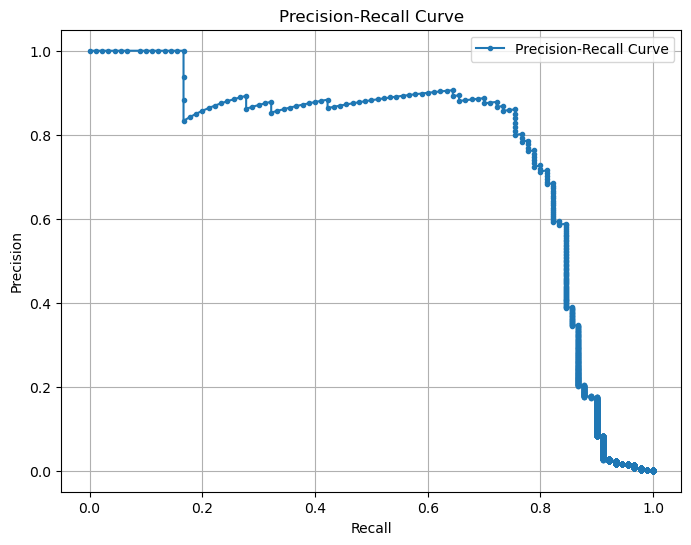

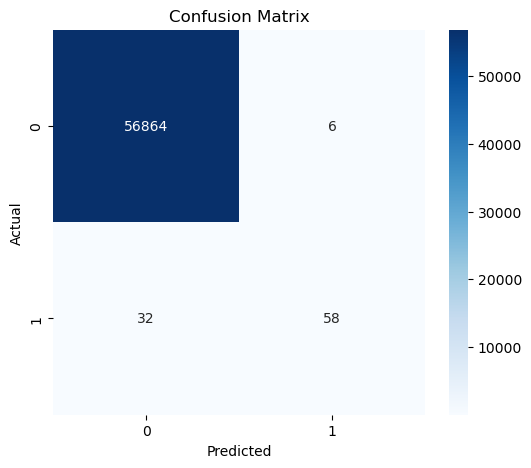

In [98]:
# استدعاء الدالة لتدريب النموذج وعرض النتائج
modelL = train_and_evaluate(X_train, y_train, X_test, y_test)

In [101]:
model2=clf2 = RandomForestClassifier(n_estimators=50, random_state=1)

In [102]:
model2.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50, random_state=1)

In [117]:
y_predict_rf=model2.predict(X_test)

In [118]:
voting_model=VotingClassifier(estimators=[("logistic",modelL),("RandomForest",model2)])

In [119]:
voting_model.fit(X_train,y_train)

VotingClassifier(estimators=[('logistic', LogisticRegression(max_iter=1000)),
                             ('RandomForest',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=1))])

In [125]:
y_predict_voting=voting_model.predict(X_test)

In [126]:
accuracy_score(y_test,voting_predict)

0.9993679775280899

In [130]:
   # طباعة نتائج النماذج
print("\nLogistic Regression:")
print("Accuracy =", accuracy_score(y_test, y_predict))
print("Classification Report:\n", classification_report(y_test, y_predict))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict))

    
print("\nRandom Forest:")
print("Accuracy =", accuracy_score(y_test, y_predict_rf))
print("Classification Report:\n", classification_report(y_test, y_predict_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_rf))
    
print("\nVoting Classifier:")
print("Best F1 Score =", best_f1_score)
print("Best Threshold =", best_thr)
print("Accuracy =", accuracy_score(y_test, y_predict_voting))
print("Classification Report:\n", classification_report(y_test, y_predict_voting))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_predict_voting))
print("ROC AUC Score =", roc_auc_score(y_test, y_predict_voting))


Logistic Regression:
Accuracy = 0.9993328651685394
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56870
           1       0.91      0.64      0.75        90

    accuracy                           1.00     56960
   macro avg       0.95      0.82      0.88     56960
weighted avg       1.00      1.00      1.00     56960

Confusion Matrix:
 [[56864     6]
 [   32    58]]

Random Forest:
Accuracy = 0.9995962078651686
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56870
           1       0.99      0.76      0.86        90

    accuracy                           1.00     56960
   macro avg       0.99      0.88      0.93     56960
weighted avg       1.00      1.00      1.00     56960

Confusion Matrix:
 [[56869     1]
 [   22    68]]

Voting Classifier:
Best F1 Score = 0.8047337278106509
Best Threshold = 0.26338579791085936
Accuracy